In [1]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from calcul_structure import *

In [2]:
## Propriété materiaux [N, m] (à modifier)
E = 1
I = 1
A = 1

#Element 1
L1 = 1 

# Nombre d'element
n_elements_ = 40
XY = np.zeros((n_elements_+1,2))
for i in range(n_elements_+1):
    XY[i, 0] = i * 1  # Setting the x-coordinate
    XY[i, 1] = 0       # Setting the y-coordinate (which is always 0 in this case)

print(XY[:,0].shape)

(41,)


In [3]:
#Matrice de rigidité élémentaire en coordonnées locales
mat_elem_local = matrice_elementaire(E, I, A, L1)

In [4]:
#Matrice de rotatio
rot_elem = rotation_matrice(0)
print(rot_elem.astype(int))

[[1 0 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 1 0 0 0]
 [0 0 0 1 0 0]
 [0 0 0 0 1 0]
 [0 0 0 0 0 1]]


In [5]:
#Matrice de rigidité élémentaire en coordonnées locales
mat_elem_global = np.matmul(np.matmul(np.transpose(rot_elem),mat_elem_local), rot_elem)

In [6]:
# Connection entre élément
# Degré de liberte de chaque élément de la forme
# LM[:, i] = [Uxi, Uyi, Thetai, Uxj, Uyj, Thetaj]
# Travée 1
LM = np.zeros((6, 41), dtype=int)
LM[:,0] = [0, 0, 38, 0, 1, 39]
LM[:,1] = [0, 1, 39, 0, 2, 40]    
LM[:,2] = [0, 2, 40, 0, 3, 41]   
LM[:,3] = [0, 3, 41, 0, 4, 42]
LM[:,4] = [0, 4, 42, 0, 5, 43]   
LM[:,5] = [0, 5, 43, 0, 6, 44]
LM[:,6] = [0, 6, 44, 0, 7, 45]
LM[:,7] = [0, 7, 45, 0, 8, 46]
LM[:,8] = [0, 8, 46, 0, 9, 47]
LM[:,9] = [0, 9, 47, 0, 10, 48]
LM[:,10] = [0, 10, 48, 0, 11, 49]
LM[:,11] = [0, 11, 49, 0, 12, 50]
LM[:,12] = [0, 12, 50, 0, 13, 51]
LM[:,13] = [0, 13, 51, 0, 14, 52]
LM[:,14] = [0, 14, 52, 0, 0, 53]

#Travée 2
LM[:,15] = [0, 0,  53, 0,  15, 54]
LM[:,16] = [0, 15, 54, 0, 16, 55]
LM[:,17] = [0, 16, 55, 0, 17, 56]
LM[:,18] = [0, 17, 56, 0, 18, 57]
LM[:,19] = [0, 18, 57, 0, 19, 58]
LM[:,20] = [0, 19, 58, 0, 20, 59]
LM[:,21] = [0, 20, 59, 0, 21, 60]
LM[:,22] = [0, 21, 60, 0, 22, 61]
LM[:,23] = [0, 22, 61, 0, 23, 62]
LM[:,24] = [0, 23, 62, 0, 0,  63]

#Travée 3
LM[:,25] = [0, 0, 63, 0, 24, 64]
LM[:,26] = [0, 24,64, 0, 25, 65]
LM[:,27] = [0, 25,65, 0, 26, 66]
LM[:,28] = [0, 26,66, 0, 27, 67]
LM[:,29] = [0, 27,67, 0, 28, 68]
LM[:,30] = [0, 28,68, 0, 29, 69]
LM[:,31] = [0, 29,69, 0, 30, 70]
LM[:,32] = [0, 30,70, 0, 31, 71]
LM[:,33] = [0, 31,71, 0, 32, 72]
LM[:,34] = [0, 32,72, 0, 33, 73]
LM[:,35] = [0, 33,73, 0, 34, 74]
LM[:,36] = [0, 34,74, 0, 35, 75]
LM[:,37] = [0, 35,75, 0, 36, 76]
LM[:,38] = [0, 36,76, 0, 37, 77]
LM[:,39] = [0, 37,77, 0, 0, 78]
#LM[:,40] = [0, 38,79, 0, 0,  80]


# Nombre de DDL
n_ddl_  = 78

In [7]:
# addtionnner au composante differentde zeros
K_global = np.zeros((n_ddl_, n_ddl_), dtype=np.float32)
for i in range(n_elements_):
    K_global = assemblage_matrice_rigidite(LM, i, K_global, mat_elem_global)


In [8]:

#Matrice de force locale (charge répartie)
w = 2846.86 #charge routière
P1_local = np.array([[0], [-w*L1/2], [-w*L1**2/12],[0],[-w*L1/2], [w*L1**2/12]])
print(P1_local)

[[    0.        ]
 [-1423.43      ]
 [ -237.23833333]
 [    0.        ]
 [-1423.43      ]
 [  237.23833333]]


In [9]:
P1_global = np.matmul(np.transpose(rot_elem),P1_local)
print(P1_global)

[[    0.        ]
 [-1423.43      ]
 [ -237.23833333]
 [    0.        ]
 [-1423.43      ]
 [  237.23833333]]


# CALCUL MOMENT FLECHISSANT ET EFFORT TRANCHANT POUR TRAVE 1 CHARGÉ

In [10]:
P_global_trave_1 = np.zeros((n_ddl_,1), dtype=np.float32)

# chargement de la travée 1
for i in range(15):
    P_global_trave_1 = assemblage_vecteur_nodal(LM, i, P_global_trave_1, P1_global)

In [11]:
#Calcule des déplacements
U_trave_1 = np.linalg.solve(K_global, P_global_trave_1)

[-24910.02539062]
41


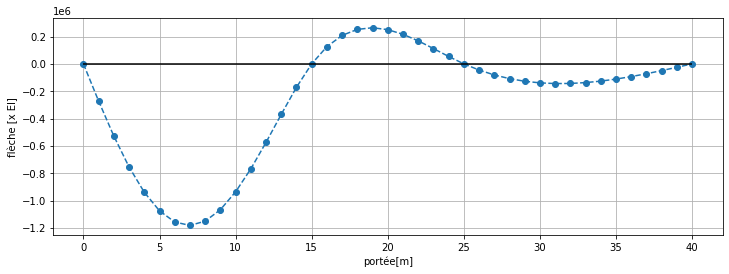

In [12]:
#Calcul des vecteurs de forces internes
deplacement_local_trave_1 = list()
for i in range(n_elements_):
    deplacement_local_trave_1.append(obtention_du_deplacement_local(LM,i, U_trave_1))

delta_deplacement_trave_1 = np.zeros(n_elements_+1)
print(deplacement_local_trave_1[-1][1])
print(len(XY))
for j in range(len(deplacement_local_trave_1)):
    delta_deplacement_trave_1[j]= deplacement_local_trave_1[j][1]
    delta_deplacement_trave_1[j+1] = deplacement_local_trave_1[j][4]
plt.figure(figsize=(12,4))
plt.grid(True)
plt.plot(XY[:,0],delta_deplacement_trave_1,'o--')
plt.hlines(0, XY[0,0], XY[-1,0], colors='black')
plt.xlabel('portée[m]')
plt.ylabel('flèche [x EI]')
plt.show()

In [13]:
effort_interne_trave_1 = list()
for i in range(n_elements_):
    effort_interne_trave_1.append(mat_elem_local@rot_elem@deplacement_local_trave_1[i])

for i in range(15):
    effort_interne_trave_1[i] = effort_interne_trave_1[i]-P1_local


[     0  16591  30336  41235  49286  54490  56847  56359  53022  46840
  37809  25933  11209  -6360 -26778 -50042 -44037 -38032 -32027 -26022
 -20016 -14011  -8006  -2001   4003  10008   9341   8674   8006   7339
   6672   6005   5337   4670   4003   3336   2668   2001   1334    667
      0]


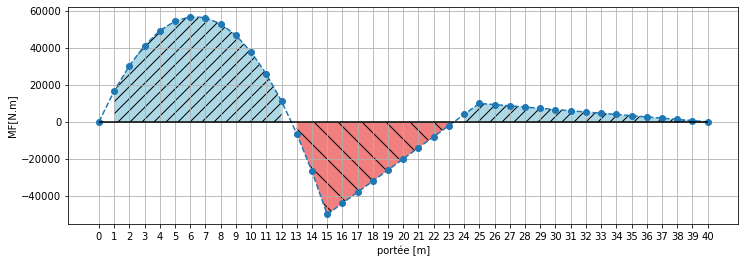

In [14]:
moment_flechissant_trave_1 =  np.zeros(n_elements_+1)
for j in range(len(effort_interne_trave_1)):
    moment_flechissant_trave_1[j] = -effort_interne_trave_1[j][2]
    moment_flechissant_trave_1[j+1] = -effort_interne_trave_1[j][5]

print(moment_flechissant_trave_1.astype(int))
x = XY[:, 0]
y = moment_flechissant_trave_1
plt.figure(figsize=(12,4))
plt.grid(True)
plt.plot(x,y,'o--')
plt.xticks(np.arange(min(x), max(x)+1, 1.0))
plt.fill_between(x, y, np.zeros_like(y), where=(y >= 0), facecolor='lightblue', hatch='//')
plt.hlines(0, XY[0,0], XY[-1,0],colors='black')
# Fill the area below the line with a different hashed pattern
plt.fill_between(x, y, np.zeros_like(y), where=(y <= 0),  facecolor='lightcoral', hatch='\\')
plt.xlabel('portée [m]')
plt.ylabel('MF[N.m]')
plt.show()

In [15]:
effort_tranchant_trave_1 =  np.zeros(n_elements_+1)
for j in range(n_elements_):
    effort_tranchant_trave_1[j] = -effort_interne_trave_1[j][1]
    effort_tranchant_trave_1[j+1] = effort_interne_trave_1[j][4]

print(effort_interne_trave_1[20][1].astype(int))

[6005]


[-18015 -15168 -12321  -9474  -6628  -3780   -935   1913   4758   7607
  10453  13300  16147  18993  21840  -6005  -6005  -6004  -6004  -6005
  -6005  -6005  -6005  -6005  -6005    667    667    667    667    667
    667    667    667    667    667    667    667    667    667    667
    667]


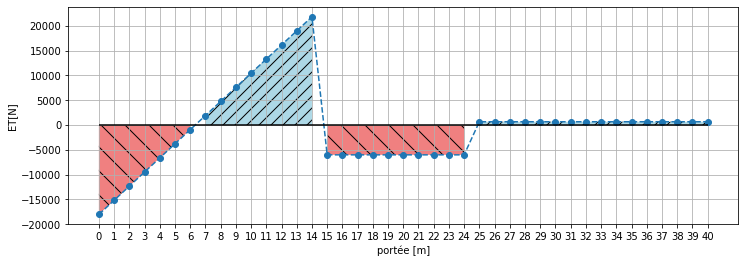

In [16]:
print(effort_tranchant_trave_1.astype(int))
y = effort_tranchant_trave_1
x = XY[:,0]
plt.figure(figsize=(12,4))
plt.grid(True)
plt.plot(x,y,'o--')
plt.xticks(np.arange(min(x), max(x)+1, 1.0))

plt.fill_between(x, y, np.zeros_like(y), where=(y >= 0), facecolor='lightblue', hatch='//')
plt.hlines(0, XY[0,0], XY[-1,0],colors='black')
# Fill the area below the line with a different hashed pattern
plt.fill_between(x, y, np.zeros_like(y), where=(y <= 0),  facecolor='lightcoral', hatch='\\')
plt.xlabel('portée [m]')
plt.ylabel('ET[N]')
plt.show()

# CALCUL MOMENT FLECHISSANT ET EFFORT TRANCHANT POUR TRAVE 2 CHARGÉ

In [17]:
P_global_trave_2 = np.zeros((n_ddl_,1), dtype=np.float32)

# chargement de la travée 2
for i in range(15,25):
    P_global_trave_2 = assemblage_vecteur_nodal(LM, i, P_global_trave_2, P1_global)

In [18]:
#Calcule des déplacements
U_trave_2 = np.linalg.solve(K_global, P_global_trave_2)

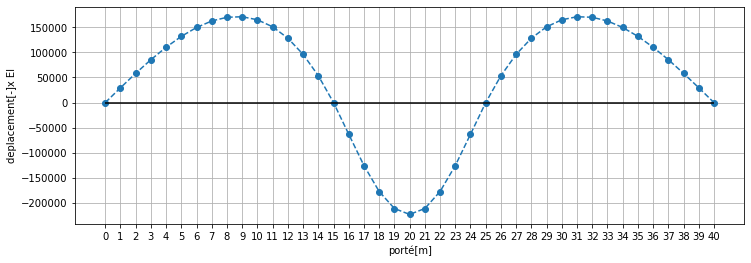

In [19]:
#Calcul des vecteurs de forces internes
deplacement_local_trave_2 = list()
for i in range(n_elements_):
    deplacement_local_trave_2.append(obtention_du_deplacement_local(LM,i, U_trave_2))

delta_deplacement_trave_2 = np.zeros(n_elements_+1)

for j in range(n_elements_):
    delta_deplacement_trave_2[j]= deplacement_local_trave_2[j][1]
    delta_deplacement_trave_2[j+1] = deplacement_local_trave_2[j][4]
plt.figure(figsize=(12,4))
plt.grid(True)
plt.xticks(np.arange(min(XY[:n_elements_+1,0]), max(XY[:n_elements_+1,0])+1, 1.0))
plt.plot(XY[:n_elements_+1,0],delta_deplacement_trave_2,'o--')
plt.hlines(0, XY[0,0], XY[-1,0], colors='black')
plt.xlabel('porté[m]')
plt.ylabel('deplacement[-]x EI')
plt.show()

In [20]:
effort_interne_trave_2 = list()
for i in range(n_elements_):
    effort_interne_trave_2.append(mat_elem_local@rot_elem@deplacement_local_trave_2[i])

for i in range(15,25):
    effort_interne_trave_2[i] = (effort_interne_trave_2[i]-P1_local)

print(effort_interne_trave_2[0][1].astype(int))

[-790]


[     0   -790  -1581  -2372  -3163  -3953  -4744  -5535  -6326  -7117
  -7907  -8698  -9489 -10280 -11071 -11861    948  10912  18030  22300
  23723  22300  18030  10912    948 -11861 -11071 -10280  -9489  -8698
  -7907  -7117  -6326  -5535  -4744  -3953  -3163  -2372  -1581   -790
      0]


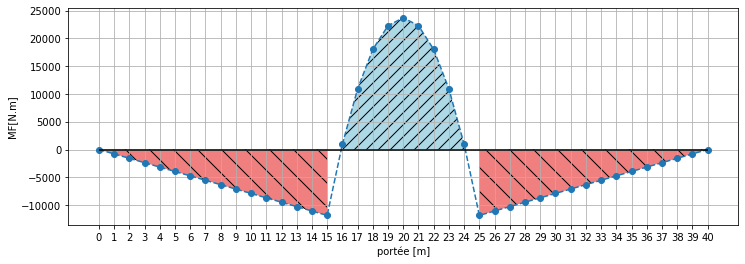

In [21]:
moment_flechissant_trave_2 =  np.zeros(n_elements_+1)
for j in range(n_elements_):
    moment_flechissant_trave_2[j] = -effort_interne_trave_2[j][2]
    moment_flechissant_trave_2[j+1] = -effort_interne_trave_2[j][5]

print(moment_flechissant_trave_2.astype(int))
x = XY[:n_elements_+1, 0]
y = moment_flechissant_trave_2
plt.figure(figsize=(12,4))
plt.grid(True)
plt.plot(x,y,'o--')
plt.xticks(np.arange(min(x), max(x)+1, 1.0))
plt.fill_between(x, y, np.zeros_like(y), where=(y >= 0), facecolor='lightblue', hatch='//')
plt.hlines(0, XY[0,0], XY[-1,0],colors='black')
# Fill the area below the line with a different hashed pattern
plt.fill_between(x, y, np.zeros_like(y), where=(y <= 0),  facecolor='lightcoral', hatch='\\')
plt.xlabel('portée [m]')
plt.ylabel('MF[N.m]')
plt.show()

In [22]:
effort_tranchant_trave_2 =  np.zeros(n_elements_+1)
for j in range(n_elements_):
    effort_tranchant_trave_2[j] = -effort_interne_trave_2[j][1]
    effort_tranchant_trave_2[j+1] = effort_interne_trave_2[j][4]

print(effort_interne_trave_2[20][1].astype(int))

[0]


[   790    790    790    790    790    790    790    790    790    790
    790    790    790    790    790 -14234 -11387  -8540  -5693  -2847
      0   2846   5693   8540  11387   -790   -790   -790   -790   -790
   -790   -790   -790   -790   -790   -790   -790   -790   -790   -790
   -790]
[-14234 -11387  -8540  -5693  -2847]


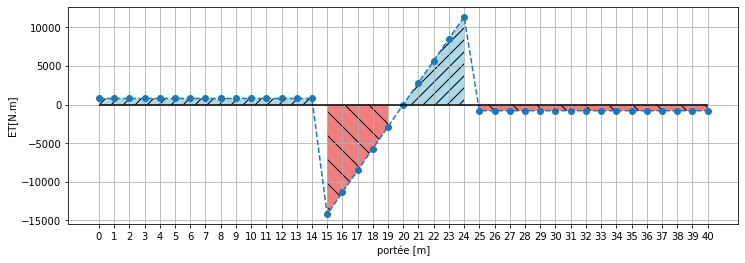

In [23]:
print(effort_tranchant_trave_2.astype(int))
x = XY[:n_elements_+1, 0]
y = effort_tranchant_trave_2
print(y[15:20].astype(int))
plt.figure(figsize=(12,4))
plt.grid(True)
plt.plot(x,y,'o--')
plt.xticks(np.arange(min(x), max(x)+1, 1.0))
plt.fill_between(x, y, np.zeros_like(y), where=(y >= 0), facecolor='lightblue', hatch='//')
plt.hlines(0, XY[0,0], XY[-1,0],colors='black')
# Fill the area below the line with a different hashed pattern
plt.fill_between(x, y, np.zeros_like(y), where=(y <= 0),  facecolor='lightcoral', hatch='\\')
plt.xlabel('portée [m]')
plt.ylabel('ET[N.m]')
plt.show()

# CALCUL MOMENT FLECHISSANT ET EFFORT TRANCHANT POUR TRAVE 1, 2 CHARGÉ

In [24]:
P_global_trave_12 = np.zeros((n_ddl_,1), dtype=np.float32)

# chargement de la travée 1
for i in range(25):
    P_global_trave_12 = assemblage_vecteur_nodal(LM, i, P_global_trave_12, P1_global)

In [25]:
#Calcule des déplacements
U_trave_12 = np.linalg.solve(K_global, P_global_trave_12)

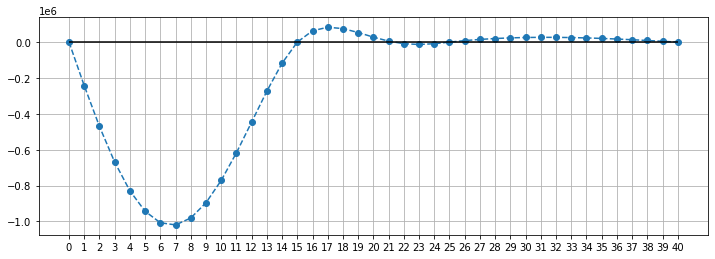

In [26]:
#Calcul des vecteurs de forces internes
deplacement_local_trave_12 = list()
for i in range(n_elements_):
    deplacement_local_trave_12.append(obtention_du_deplacement_local(LM,i, U_trave_12))

delta_deplacement_trave_12 = np.zeros(n_elements_+1)

for j in range(n_elements_):
    delta_deplacement_trave_12[j]= deplacement_local_trave_12[j][1]
    delta_deplacement_trave_12[j+1] = deplacement_local_trave_12[j][4]
plt.figure(figsize=(12,4))
plt.grid(True)
plt.plot(XY[:n_elements_+1,0],delta_deplacement_trave_12,'o--')
plt.xticks(np.arange(min(x), max(x)+1, 1.0))
plt.hlines(0, XY[0,0], XY[-1,0], colors='black')
plt.show()

In [27]:
effort_interne_trave_12 = list()
for i in range(n_elements_):
    effort_interne_trave_12.append(mat_elem_local@rot_elem@deplacement_local_trave_12[i])

for i in range(0,25):
    effort_interne_trave_12[i] = effort_interne_trave_12[i]-P1_local

print(effort_interne_trave_12[0][1].astype(int))

[17224]


[     0  15800  28755  38862  46123  50536  52103  50823  46696  39722
  29901  17234   1720 -16641 -37849 -61904 -43088 -27119 -13997  -3721
   3706   8288  10023   8911   4952  -1853  -1729  -1606  -1482  -1359
  -1235  -1112   -988   -864   -741   -617   -494   -370   -247   -123
      0]


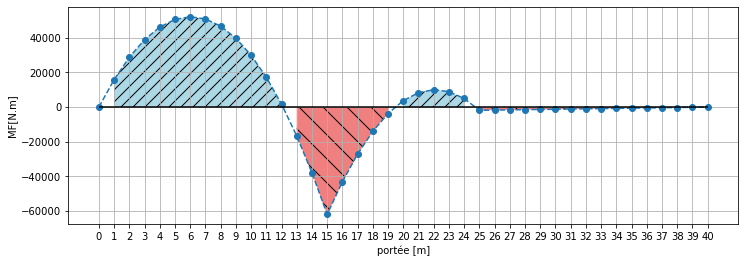

In [28]:
moment_flechissant_trave_12 =  np.zeros(n_elements_+1)
for j in range(n_elements_):
    moment_flechissant_trave_12[j] = -effort_interne_trave_12[j][2]
    moment_flechissant_trave_12[j+1] = -effort_interne_trave_12[j][5]

print(moment_flechissant_trave_12.astype(int))
x = XY[:n_elements_+1, 0]
y = moment_flechissant_trave_12
plt.figure(figsize=(12,4))
plt.grid(True)
plt.plot(x,y,'o--')
plt.xticks(np.arange(min(x), max(x)+1, 1.0))
plt.fill_between(x, y, np.zeros_like(y), where=(y >= 0), facecolor='lightblue', hatch='//')
plt.hlines(0, XY[0,0], XY[-1,0],colors='black')
# Fill the area below the line with a different hashed pattern
plt.fill_between(x, y, np.zeros_like(y), where=(y <= 0),  facecolor='lightcoral', hatch='\\')
plt.xlabel('portée [m]')
plt.ylabel('MF[N.m]')
plt.show()

In [29]:
effort_tranchant_trave_12 =  np.zeros(n_elements_+1)
for j in range(n_elements_):
    effort_tranchant_trave_12[j] = -effort_interne_trave_12[j][1]
    effort_tranchant_trave_12[j+1] = effort_interne_trave_12[j][4]

print(effort_interne_trave_12[20][1].astype(int))

[6005]


[-17224 -14377 -11530  -8684  -5837  -2989   -143   2703   5550   8397
  11244  14090  16937  19784  22631 -20239 -17392 -14545 -11698  -8851
  -6005  -3158   -311   2535   5382   -123   -123   -123   -123   -123
   -123   -123   -123   -123   -123   -123   -123   -123   -123   -123
   -123]
[-20239 -17392 -14545 -11698  -8851]


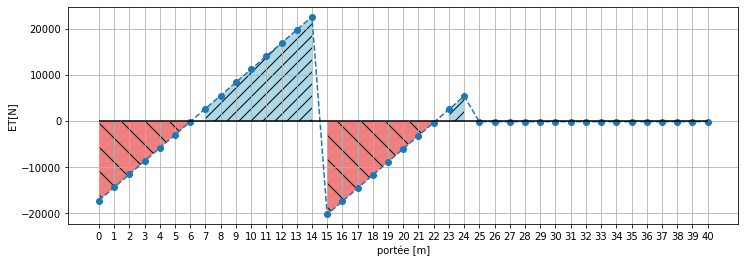

In [30]:
print(effort_tranchant_trave_12.astype(int))
x = XY[:n_elements_+1, 0]
y = effort_tranchant_trave_12
print(y[15:20].astype(int))
plt.figure(figsize=(12,4))
plt.grid(True)
plt.plot(x,y,'o--')
plt.xticks(np.arange(min(x), max(x)+1, 1.0))
plt.fill_between(x, y, np.zeros_like(y), where=(y >= 0), facecolor='lightblue', hatch='//')
plt.hlines(0, XY[0,0], XY[-1,0],colors='black')
# Fill the area below the line with a different hashed pattern
plt.fill_between(x, y, np.zeros_like(y), where=(y <= 0),  facecolor='lightcoral', hatch='\\')
plt.xlabel('portée [m]')
plt.ylabel('ET[N]')
plt.show()

# CALCUL MOMENT FLECHISSANT ET EFFORT TRANCHANT POUR TRAVE 1, 3 CHARGÉ

In [31]:
P_global_trave_13 = np.zeros((n_ddl_,1), dtype=np.float32)

# chargement de la travée 1
for i in range(0, 15):
    P_global_trave_13 = assemblage_vecteur_nodal(LM, i, P_global_trave_13, P1_global)

for i in range(25, 40):
    P_global_trave_13 = assemblage_vecteur_nodal(LM, i, P_global_trave_13, P1_global)


In [32]:
#Calcule des déplacements
U_trave_13 = np.linalg.solve(K_global, P_global_trave_13)

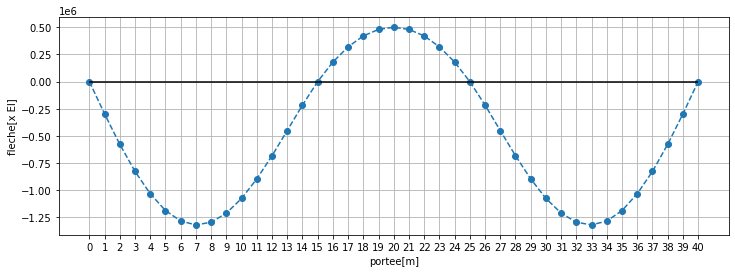

In [33]:
#Calcul des vecteurs de forces internes
deplacement_local_trave_13 = list()
for i in range(n_elements_):
    deplacement_local_trave_13.append(obtention_du_deplacement_local(LM,i, U_trave_13))

delta_deplacement_trave_13 = np.zeros(n_elements_+1)

for j in range(n_elements_):
    delta_deplacement_trave_13[j]= deplacement_local_trave_13[j][1]
    delta_deplacement_trave_13[j+1] = deplacement_local_trave_13[j][4]
plt.figure(figsize=(12,4))
plt.grid(True)
plt.plot(XY[:n_elements_+1,0],delta_deplacement_trave_13,'o--')
plt.xticks(np.arange(min(x), max(x)+1, 1.0))
plt.hlines(0, XY[0,0], XY[-1,0], colors='black')
plt.xlabel('portee[m]')
plt.ylabel('fleche[x EI]')
plt.show()

In [34]:
effort_interne_trave_13 = list()
for i in range(n_elements_):
    effort_interne_trave_13.append(mat_elem_local@rot_elem@deplacement_local_trave_13[i])

for i in range(15):
    effort_interne_trave_13[i] = effort_interne_trave_13[i]-P1_local

for i in range(25,40):
    effort_interne_trave_13[i] = effort_interne_trave_13[i]-P1_local

print(effort_interne_trave_12[0][1].astype(int))

[17224]


[     0  17259  31671  43236  51955  57827  60851  61030  58360  52844
  44482  33272  19216   2313 -17436 -40033 -40033 -40033 -40033 -40034
 -40033 -40034 -40034 -40033 -40033 -40034 -17436   2312  19216  33272
  44482  52845  58360  61030  60851  57826  51955  43236  31671  17259
      0]


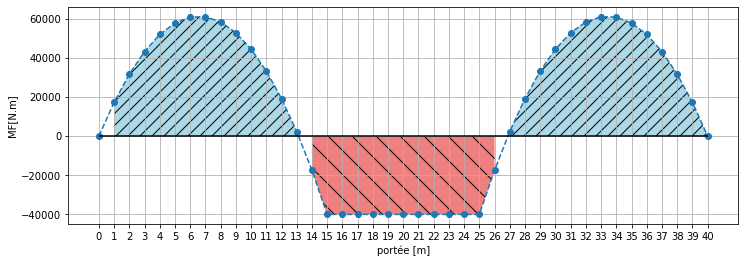

In [35]:
moment_flechissant_trave_13 =  np.zeros(n_elements_+1)
for j in range(n_elements_):
    moment_flechissant_trave_13[j] = -effort_interne_trave_13[j][2]
    moment_flechissant_trave_13[j+1] = -effort_interne_trave_13[j][5]

print(moment_flechissant_trave_13.astype(int))
x = XY[:n_elements_+1, 0]
y = moment_flechissant_trave_13
plt.figure(figsize=(12,4))
plt.grid(True)
plt.plot(x,y,'o--')
plt.xticks(np.arange(min(x), max(x)+1, 1.0))
plt.fill_between(x, y, np.zeros_like(y), where=(y >= 0), facecolor='lightblue', hatch='//')
plt.hlines(0, XY[0,0], XY[-1,0],colors='black')
# Fill the area below the line with a different hashed pattern
plt.fill_between(x, y, np.zeros_like(y), where=(y <= 0),  facecolor='lightcoral', hatch='\\')
plt.xlabel('portée [m]')
plt.ylabel('MF[N.m]')
plt.show()

In [36]:
effort_tranchant_trave_13 =  np.zeros(n_elements_+1)
for j in range(0,n_elements_):
    effort_tranchant_trave_13[j] = -effort_interne_trave_13[j][1]
    effort_tranchant_trave_13[j+1] = effort_interne_trave_13[j][4]


[-18682 -15835 -12988 -10142  -7295  -4447  -1602   1246   4091   6938
   9786  12632  15480  18326  21173      0      0      0      0      0
      0      0      0      0      0 -24020 -21173 -18326 -15479 -12633
  -9785  -6938  -4093  -1244   1600   4448   7295  10141  12988  15835
  18682]


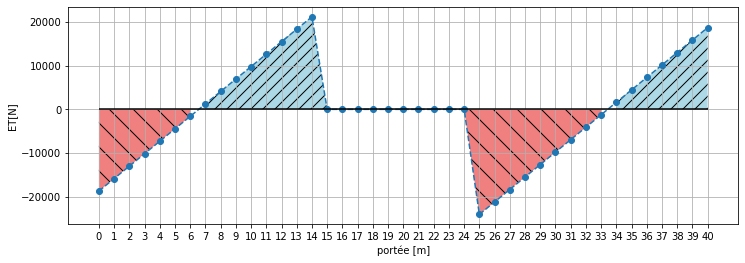

In [37]:
print(effort_tranchant_trave_13.astype(int))
x = XY[:n_elements_+1, 0]
y = effort_tranchant_trave_13

plt.figure(figsize=(12,4))
plt.grid(True)
plt.plot(x,y,'o--')
plt.xticks(np.arange(min(x), max(x)+1, 1.0))
plt.fill_between(x, y, np.zeros_like(y), where=(y >= 0), facecolor='lightblue', hatch='//')
plt.hlines(0, XY[0,0], XY[-1,0],colors='black')
# Fill the area below the line with a different hashed pattern
plt.fill_between(x, y, np.zeros_like(y), where=(y <= 0),  facecolor='lightcoral', hatch='\\')
plt.xlabel('portée [m]')
plt.ylabel('ET[N]')
plt.show()